In [21]:
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt

In [22]:
data= pd.read_csv('data8/공공보건의료기관현황.csv', 
                  encoding='cp949')
data

,연번,병원 명,설립형태,근거 법령,관계 행정기관,관계 공공단체,심평원 요양기관번호,종별구분,병상수,소재지 우편번호,주소,홈페이지,대표전화,FAX,비고
0,1,강원도 재활병원,시도립,강원도재활병원설치및운영에관한조례,강원도,해당없음,32200641,병원,165,24227,강원도 춘천시 충열로 142번길 24-16,www.grh.or.kr,033-248-7700,033-248-7723,NaN
1,2,강원도 삼척의료원,특수법인,지방의료원의 설립 및 운영에 관한 법률,보건복지부(강원도),지방의료원,32100060,종합병원,152,25920,강원도 삼척시 오십천로 418,http://ksmc.or.kr,033-572-1141,033-573-8424,NaN
2,3,강원도 영월의료원,특수법인,지방의료원의 설립 및 운영에 관한 법률,보건복지부(강원도),지방의료원,32100078,종합병원,214,26234,강원도 영월군 영월읍 중앙1로 59,http://www.youngwol.org,033-370-9117,033-370-9137,NaN
3,4,강원도 원주의료원,특수법인,지방의료원의 설립 및 운영에 관한 법률,보건복지부(강원도),지방의료원,32100086,종합병원,237,26448,강원도 원주시 서원대로 387(개운동),www.kwmc.or.kr,033-760-4500,033-761-5121,NaN
4,5,강원도 강릉의료원,특수법인,지방의료원의 설립 및 운영에 관한 법률,보건복지부(강원도),지방의료원,32100159,종합병원,137,25535,강원도 강릉시 경강로 2007(남문동 164-1),http://www.gnmc.or.kr,033-646-6910,033-610-1415,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,216,청풍호노인사랑병원,시군구립,제천시 노인전문병원 설치및 운영에 관한 조례,충청북도,해당없음,33280576,요양병원,187,27207,충청북도 제천시 금성면 청풍호로 1147,www.cplove.co.kr,043-646-0808,043-648-5827,NaN
223,217,충주시 노인전문병원,시군구립,충주시노인전문병원설치 및 운영에관한 조례,충청북도,해당없음,33280088,요양병원,300,27442,충청북도 충주시 동량면 대전리 1686-28,www.hyolife.com,043-855-9393,043-855-8866,NaN
224,218,충청북도 충주의료원,특수법인,지방의료원의 설립 및 운영에 관한 법률,충청북도,해당없음,33100063,종합병원,292,27468,충청북도 충주시 안림로 239-50(안림동 134),www.cjmct.or.kr,043-871-0114,043-843-4231,NaN
225,219,영동군립노인전문병원,시군구립,영동군립노인전문병원설치 및 운영조례,충청북도,해당없음,33280681,요양병원,120,29131,충청북도 영동군 영동읍 대학로 290,cmisilveryd.com,043-744-9633,043-742-8275,NaN


In [23]:
addr=pd.DataFrame(data['주소'].apply(lambda x: x.split()[:2]).tolist(),
                  columns=['시도','군구'])
addr

,시도,군구
0,강원도,춘천시
1,강원도,삼척시
2,강원도,영월군
3,강원도,원주시
4,강원도,강릉시
...,...,...
222,충청북도,제천시
223,충청북도,충주시
224,충청북도,충주시
225,충청북도,영동군


In [24]:
addr['시도'].unique()

array(['강원도', '경기도', '경기', '경남', '창원시', '경상남도', '경상북도', '경산시', '경북',
       '인천광역시', '대구광역시', '전라남도', '대전광역시', '광주광역시', '제주특별자치도', '부산광역시',
       '전라북도', '충북', '서울특별시', '서울시', '부산특별시', '대전시', '충남', '전남', '충청남도',
       '울산광역시', '전북', '천안시', '충청북도'], dtype=object)

In [25]:
addr[addr['시도']=='창원시']

,시도,군구
27,창원시,의창구
31,창원시,마산합포구3.15대로


In [26]:
addr.iloc[27]=['경상남도', '창원시']
addr.iloc[31]=['경상남도', '창원시']

In [27]:
addr[addr['시도']=='경산시']

,시도,군구
47,경산시,경안로


In [28]:
addr.iloc[47]=['경상북도', '경산시']
addr[addr['시도']=='경산시']

,시도,군구


In [29]:
addr[addr['시도']=='천안시']

,시도,군구
209,천안시,동남구
210,천안시,동남구


In [30]:
addr.iloc[209]=['충청남도', '천안시']
addr.iloc[210]=['충청남도', '천안시']
addr[addr['시도']=='천안시']

,시도,군구


In [31]:
addr['시도'].unique()

array(['강원도', '경기도', '경기', '경남', '경상남도', '경상북도', '경북', '인천광역시', '대구광역시',
       '전라남도', '대전광역시', '광주광역시', '제주특별자치도', '부산광역시', '전라북도', '충북',
       '서울특별시', '서울시', '부산특별시', '대전시', '충남', '전남', '충청남도', '울산광역시', '전북',
       '충청북도'], dtype=object)

In [34]:
addr_aliases={'서울시': '서울특별시',
              '부산특별시': '부산광역시',
              '대전시': '대전광역시',
            
              '경기': '경기도',
              '경남': '경상남도',
              '경북': '경상북도',
              '충남': '충청남도',
              '충북': '충청북도',
              '전남': '전라남도',
              '전북': '전북특별자치도',
              '강원도': '강원특별자치도',}
addr['시도']=addr['시도'].replace(addr_aliases)
addr['시도'].unique()

array(['강원특별자치도', '경기도', '경상남도', '경상북도', '인천광역시', '대구광역시', '전라남도',
       '대전광역시', '광주광역시', '제주특별자치도', '부산광역시', '전라북도', '충청북도', '서울특별시',
       '충청남도', '울산광역시', '전북특별자치도'], dtype=object)

In [35]:
addr['군구'].unique()

array(['춘천시', '삼척시', '영월군', '원주시', '강릉시', '속초시', '정선군', '수원시', '이천시',
       '안성시', '의정부시', '포천시', '파주시', '용인시', '평택시', '시흥시', '여주시', '남양주시',
       '동두천시', '안산시', '부천시', '통영시', '사천시', '창원시', '김해시', '양산시', '거창군',
       '남해군', '의령군', '포항시', '김천시', '안동시', '울진군', '경주시', '구미시', '영주시',
       '상주시', '문경시', '경산시', '의성군', '청도군', '고령군', '칠곡군', '봉화군', '울릉군',
       '부평구', '북구', '순천시', '대덕구', '태백시', '동해시', '화성시', '광산구', '남구', '중구',
       '아란13길', '서구', '전주시', '진주시', '청주시', '종로구', '성남시', '동구', '화순군',
       '강동구', '사상구', '달서구', '해운대구', '유성구', '가평군', '양주시', '고양시', '홍천군',
       '양구군', '청원군', '계룡시', '논산시', '함평군', '양평군', '수성구', '달성군', '연수구',
       '노원구', '기장군', '공주시', '강북구', '광진구', '나주시', '창녕군', '목포시', '고흥군',
       '연제구', '동매로', '서초구', '은평구', '중랑구', '강남구', '동작구', '동대문구', '양천구',
       '성동구', '송파구', '울주군', '계양구', '옹진군', '보성군', '광양시', '영광군', '무안군',
       '진도군', '강진군', '곡성군', '여수시', '신안군', '장성군', '완주군', '부안군', '정읍시',
       '남원시', '군산시', '고창군', '진안군', '제주시', '서귀포시', '천안시', '보령시', '서산시',
       '서천

In [37]:
addr[addr['군구']=='아란13길']
addr.iloc[75]=['제주특별자치도', '제주시']
addr[addr['군구']=='아란13길']

,시도,군구


In [38]:
addr['시도군구']=addr['시도']+' '+addr['군구']
addr

,시도,군구,시도군구
0,강원특별자치도,춘천시,강원특별자치도 춘천시
1,강원특별자치도,삼척시,강원특별자치도 삼척시
2,강원특별자치도,영월군,강원특별자치도 영월군
3,강원특별자치도,원주시,강원특별자치도 원주시
4,강원특별자치도,강릉시,강원특별자치도 강릉시
...,...,...,...
222,충청북도,제천시,충청북도 제천시
223,충청북도,충주시,충청북도 충주시
224,충청북도,충주시,충청북도 충주시
225,충청북도,영동군,충청북도 영동군


In [39]:
addr['count']=0
addr

,시도,군구,시도군구,count
0,강원특별자치도,춘천시,강원특별자치도 춘천시,0
1,강원특별자치도,삼척시,강원특별자치도 삼척시,0
2,강원특별자치도,영월군,강원특별자치도 영월군,0
3,강원특별자치도,원주시,강원특별자치도 원주시,0
4,강원특별자치도,강릉시,강원특별자치도 강릉시,0
...,...,...,...,...
222,충청북도,제천시,충청북도 제천시,0
223,충청북도,충주시,충청북도 충주시,0
224,충청북도,충주시,충청북도 충주시,0
225,충청북도,영동군,충청북도 영동군,0


In [41]:
addr_group= addr.groupby(['시도','군구','시도군구'], as_index=False).count()
addr_group

,시도,군구,시도군구,count
0,강원특별자치도,강릉시,강원특별자치도 강릉시,4
1,강원특별자치도,동해시,강원특별자치도 동해시,1
2,강원특별자치도,삼척시,강원특별자치도 삼척시,1
3,강원특별자치도,속초시,강원특별자치도 속초시,1
4,강원특별자치도,양구군,강원특별자치도 양구군,1
...,...,...,...,...
135,충청북도,영동군,충청북도 영동군,1
136,충청북도,제천시,충청북도 제천시,1
137,충청북도,청원군,충청북도 청원군,1
138,충청북도,청주시,충청북도 청주시,4


In [43]:
addr_group.set_index('시도군구',inplace=True)
addr_group

,시도,군구,count
시도군구,,,
강원특별자치도 강릉시,강원특별자치도,강릉시,4
강원특별자치도 동해시,강원특별자치도,동해시,1
강원특별자치도 삼척시,강원특별자치도,삼척시,1
강원특별자치도 속초시,강원특별자치도,속초시,1
강원특별자치도 양구군,강원특별자치도,양구군,1
...,...,...,...
충청북도 영동군,충청북도,영동군,1
충청북도 제천시,충청북도,제천시,1
충청북도 청원군,충청북도,청원군,1


In [45]:
population=pd.read_excel('data8/행정구역_시군구_별__성별_인구수_2.xlsx')
population

,시도,군구,총인구수,남자인구수,여자인구수
0,전국,합계,51313912,25558944,25754968
1,서울특별시,소계,9384325,4538354,4845971
2,서울특별시,종로구,139378,67240,72138
3,서울특별시,중구,121322,58651,62671
4,서울특별시,용산구,212175,101793,110382
...,...,...,...,...,...
288,경상남도,거창군,59909,29480,30429
289,경상남도,합천군,41096,20094,21002
290,제주특별자치도,소계,674353,337578,336775
291,제주특별자치도,제주시,490888,245197,245691


In [47]:
population['군구']=population['군구'].apply(lambda x: x.strip())
population['군구'].unique()
population['시도']=population['시도'].apply(lambda x: x.strip())
population['시도'].unique()

array(['전국', '서울특별시', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시',
       '울산광역시', '세종특별자치시', '경기도', '강원특별자치도', '충청북도', '충청남도', '전북특별자치도',
       '전라남도', '경상북도', '경상남도', '제주특별자치도'], dtype=object)

In [48]:
population['시도군구']=population['시도']+' '+population['군구']
population

,시도,군구,총인구수,남자인구수,여자인구수,시도군구
0,전국,합계,51313912,25558944,25754968,전국 합계
1,서울특별시,소계,9384325,4538354,4845971,서울특별시 소계
2,서울특별시,종로구,139378,67240,72138,서울특별시 종로구
3,서울특별시,중구,121322,58651,62671,서울특별시 중구
4,서울특별시,용산구,212175,101793,110382,서울특별시 용산구
...,...,...,...,...,...,...
288,경상남도,거창군,59909,29480,30429,경상남도 거창군
289,경상남도,합천군,41096,20094,21002,경상남도 합천군
290,제주특별자치도,소계,674353,337578,336775,제주특별자치도 소계
291,제주특별자치도,제주시,490888,245197,245691,제주특별자치도 제주시


In [50]:
population=population[population['군구']!='합계']
population=population[population['군구']!='소계']
population.set_index('시도군구', inplace=True)
population

,시도,군구,총인구수,남자인구수,여자인구수
시도군구,,,,,
서울특별시 종로구,서울특별시,종로구,139378,67240,72138
서울특별시 중구,서울특별시,중구,121322,58651,62671
서울특별시 용산구,서울특별시,용산구,212175,101793,110382
서울특별시 성동구,서울특별시,성동구,277090,134390,142700
서울특별시 광진구,서울특별시,광진구,335335,161154,174181
...,...,...,...,...,...
경상남도 함양군,경상남도,함양군,36873,17894,18979
경상남도 거창군,경상남도,거창군,59909,29480,30429
경상남도 합천군,경상남도,합천군,41096,20094,21002


In [ ]:
merged=pd.merge(addr_group, population, on='시도군구', how='inner')
merged['총인구수']

,시도_x,군구_x,count,시도_y,군구_y,총인구수,남자인구수,여자인구수
시도군구,,,,,,,,
강원특별자치도 강릉시,강원특별자치도,강릉시,4,강원특별자치도,강릉시,209174,103616,105558
강원특별자치도 동해시,강원특별자치도,동해시,1,강원특별자치도,동해시,88591,45007,43584
강원특별자치도 삼척시,강원특별자치도,삼척시,1,강원특별자치도,삼척시,62309,31645,30664
강원특별자치도 속초시,강원특별자치도,속초시,1,강원특별자치도,속초시,82021,40606,41415
강원특별자치도 양구군,강원특별자치도,양구군,1,강원특별자치도,양구군,20975,10994,9981
...,...,...,...,...,...,...,...,...
충청북도 단양군,충청북도,단양군,1,충청북도,단양군,27680,14076,13604
충청북도 영동군,충청북도,영동군,1,충청북도,영동군,44120,22138,21982
충청북도 제천시,충청북도,제천시,1,충청북도,제천시,129852,65296,64556


In [66]:
#merged=merged[['시도_x','군구_x','count','총인구수']]
merged.columns=['시도','군구','count','인구수']
merged['MC_ratio']=merged['count']/merged['인구수']*100000
merged

,시도,군구,count,인구수,MC_ratio
시도군구,,,,,
강원특별자치도 강릉시,강원특별자치도,강릉시,4,209174,1.912284
강원특별자치도 동해시,강원특별자치도,동해시,1,88591,1.128783
강원특별자치도 삼척시,강원특별자치도,삼척시,1,62309,1.604905
강원특별자치도 속초시,강원특별자치도,속초시,1,82021,1.219200
강원특별자치도 양구군,강원특별자치도,양구군,1,20975,4.767580
...,...,...,...,...,...
충청북도 단양군,충청북도,단양군,1,27680,3.612717
충청북도 영동군,충청북도,영동군,1,44120,2.266546
충청북도 제천시,충청북도,제천시,1,129852,0.770108


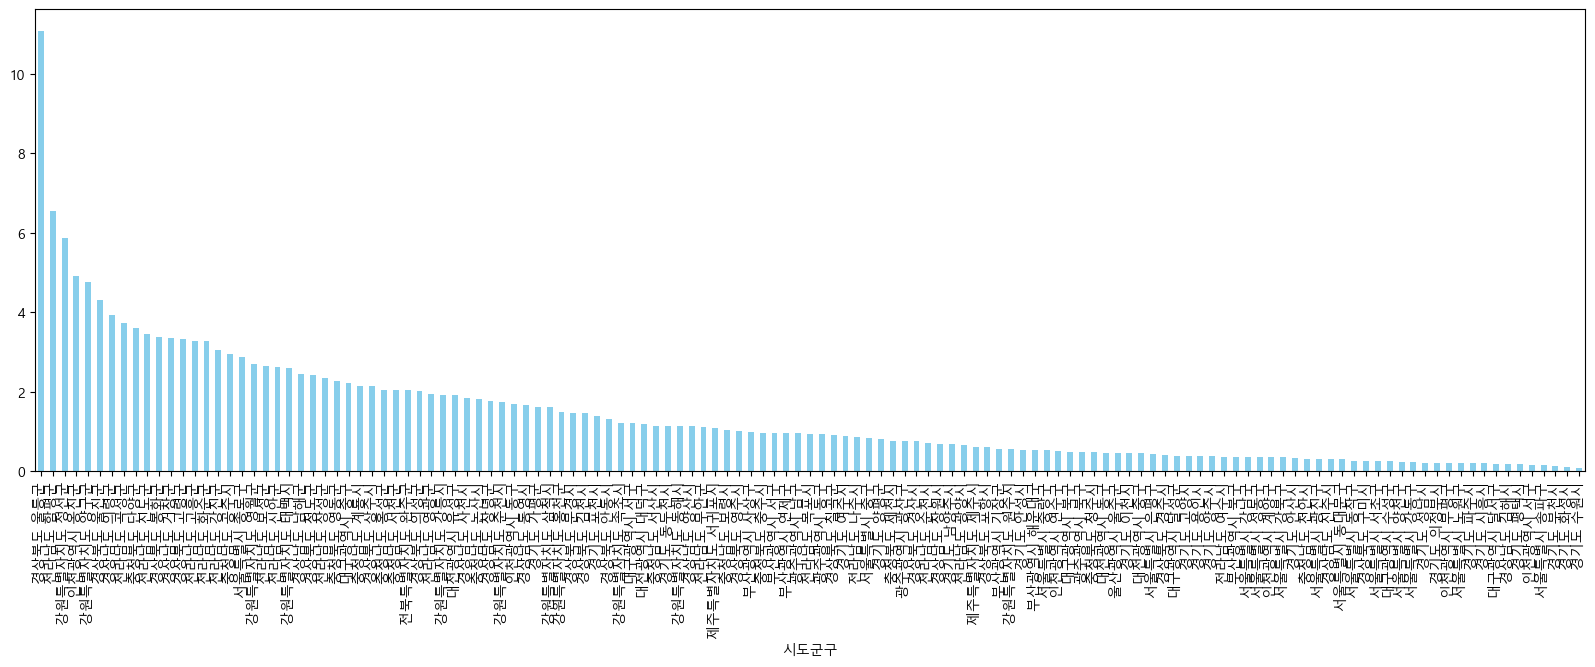

In [68]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(20, 6))
mc_ratio = merged['MC_ratio'].sort_values(ascending=False)
mc_ratio.plot(kind='bar', color='skyblue',rot=90)
plt.show()


In [70]:
merged

,시도,군구,count,인구수,MC_ratio
시도군구,,,,,
강원특별자치도 강릉시,강원특별자치도,강릉시,4,209174,1.912284
강원특별자치도 동해시,강원특별자치도,동해시,1,88591,1.128783
강원특별자치도 삼척시,강원특별자치도,삼척시,1,62309,1.604905
강원특별자치도 속초시,강원특별자치도,속초시,1,82021,1.219200
강원특별자치도 양구군,강원특별자치도,양구군,1,20975,4.767580
...,...,...,...,...,...
충청북도 단양군,충청북도,단양군,1,27680,3.612717
충청북도 영동군,충청북도,영동군,1,44120,2.266546
충청북도 제천시,충청북도,제천시,1,129852,0.770108


In [71]:
data_draw_korea = pd.read_csv('data8/data_draw_korea.csv')
data_draw_korea

,Unnamed: 0,인구수,shortName,x,y,면적,광역시도,행정구역
0,0,202520,강릉,11,4,1040.07,강원도,강릉시
1,1,25589,고성(강원),9,0,664.19,강원도,고성군
2,2,86747,동해,11,5,180.01,강원도,동해시
3,3,63986,삼척,11,8,1185.80,강원도,삼척시
4,4,76733,속초,9,1,105.25,강원도,속초시
...,...,...,...,...,...,...,...,...
224,224,127462,제천,8,10,882.47,충청북도,제천시
225,225,34480,증평,6,11,81.84,충청북도,증평군
226,226,62809,진천,5,11,406.08,충청북도,진천군
227,227,790216,청주,6,12,932.51,충청북도,청주시


In [72]:
addr_aliases={'강원도':'강원특별자치도',
              '전라북도':'전북특별자치도'}
data_draw_korea['광역시도'] = data_draw_korea['광역시도'].replace(addr_aliases)
data_draw_korea['광역시도'].unique()

array(['강원특별자치도', '경기도', '경상남도', '경상북도', '광주광역시', '대구광역시', '대전광역시',
       '부산광역시', '서울특별시', '세종특별자치시', '울산광역시', '인천광역시', '전라남도', '전북특별자치도',
       '제주특별자치도', '충청남도', '충청북도'], dtype=object)

In [74]:
data_draw_korea['시도군구']= data_draw_korea['광역시도'] + ' ' + data_draw_korea['행정구역']
data_draw_korea.set_index('시도군구', inplace=True)
data_draw_korea

,Unnamed: 0,인구수,shortName,x,y,면적,광역시도,행정구역
시도군구,,,,,,,,
강원특별자치도 강릉시,0,202520,강릉,11,4,1040.07,강원특별자치도,강릉시
강원특별자치도 고성군,1,25589,고성(강원),9,0,664.19,강원특별자치도,고성군
강원특별자치도 동해시,2,86747,동해,11,5,180.01,강원특별자치도,동해시
강원특별자치도 삼척시,3,63986,삼척,11,8,1185.80,강원특별자치도,삼척시
강원특별자치도 속초시,4,76733,속초,9,1,105.25,강원특별자치도,속초시
...,...,...,...,...,...,...,...,...
충청북도 제천시,224,127462,제천,8,10,882.47,충청북도,제천시
충청북도 증평군,225,34480,증평,6,11,81.84,충청북도,증평군
충청북도 진천군,226,62809,진천,5,11,406.08,충청북도,진천군


In [75]:
data_draw_korea_merged = pd.merge(data_draw_korea, merged, on='시도군구', how='outer')
data_draw_korea_merged

,Unnamed: 0,인구수_x,shortName,x,y,면적,광역시도,행정구역,시도,군구,count,인구수_y,MC_ratio
시도군구,,,,,,,,,,,,,
강원특별자치도 강릉시,0,202520,강릉,11,4,1040.07,강원특별자치도,강릉시,강원특별자치도,강릉시,4.0,209174.0,1.912284
강원특별자치도 고성군,1,25589,고성(강원),9,0,664.19,강원특별자치도,고성군,NaN,NaN,NaN,NaN,NaN
강원특별자치도 동해시,2,86747,동해,11,5,180.01,강원특별자치도,동해시,강원특별자치도,동해시,1.0,88591.0,1.128783
강원특별자치도 삼척시,3,63986,삼척,11,8,1185.80,강원특별자치도,삼척시,강원특별자치도,삼척시,1.0,62309.0,1.604905
강원특별자치도 속초시,4,76733,속초,9,1,105.25,강원특별자치도,속초시,강원특별자치도,속초시,1.0,82021.0,1.219200
...,...,...,...,...,...,...,...,...,...,...,...,...,...
충청북도 제천시,224,127462,제천,8,10,882.47,충청북도,제천시,충청북도,제천시,1.0,129852.0,0.770108
충청북도 증평군,225,34480,증평,6,11,81.84,충청북도,증평군,NaN,NaN,NaN,NaN,NaN
충청북도 진천군,226,62809,진천,5,11,406.08,충청북도,진천군,NaN,NaN,NaN,NaN,NaN


In [76]:
BORDER_LINES = [
    [(3, 2), (5, 2), (5, 3), (9, 3), (9, 1)], # 인천
    [ (2, 5), (3, 5), (3, 4), (8, 4), (8, 7), (7, 7), (7, 9), (4, 9),
    (4, 7), (1, 7)], # 서울
    [(1, 6), (1, 9), (3, 9), (3, 10), (8, 10), (8, 9),
    (9, 9), (9, 8), (10, 8), (10, 5), (9, 5), (9, 3)], # 경기도
    [(9, 12), (9, 10), (8, 10)], # 강원도
    [(10, 5), (11, 5), (11, 4), (12, 4), (12, 5), (13, 5),
    (13, 4), (14, 4), (14, 2)], # 충청남도
    [(11, 5), (12, 5), (12, 6), (15, 6), (15, 7), (13, 7),
    (13, 8), (11, 8), (11, 9), (10, 9), (10, 8)], # 충청북도
    [(14, 4), (15, 4), (15, 6)], # 대전시
    [(14, 7), (14, 9), (13, 9), (13, 11), (13, 13)], # 경상북도
    [(14, 8), (16, 8), (16, 10), (15, 10),
    (15, 11), (14, 11), (14, 12), (13, 12)], # 대구시
    [(15, 11), (16, 11), (16, 13)], # 울산시
    [(17, 1), (17, 3), (18, 3), (18, 6), (15, 6)], # 전라북도
    [ (19, 2), (19, 4), (21, 4), (21, 3), (22, 3), (22, 2), (19, 2)], #광주시
    [(18, 5), (20, 5), (20, 6)], # 전라남도
    [ (16, 9), (18, 9), (18, 8), (19, 8), (19, 9), (20, 9), (20, 10)], #부산시
]